# Do Tumors Recapitulate Fetal Mitotic Gene Expression Programs?

This notebook investigates whether tumor gene expression profiles resemble fetal developmental programs, focusing on mitotic genes.

We compare tumor and fetal RNA-seq data using:
- PCA for global structure
- correlation-based distance for pattern similarity

The goal is to determine whether tumor proliferation reflects fetal-like transcriptional states.

## Reproducibility Note

This notebook uses repo-root-aware paths so it can run whether launched from the repository root or from the `notebooks/` folder.

In [32]:
from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

print("Current working directory:", Path.cwd())

cwd = Path.cwd()

if (cwd / "data").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "data").exists():
    REPO_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find repo root containing 'data/'")

DATA_DIR = REPO_ROOT / "data"
RESULTS_DIR = REPO_ROOT / "results"

FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

tpm_path = DATA_DIR / "tcga" / "TcgaTargetGtex_rsem_gene_tpm.gz"
pheno_path = DATA_DIR / "tcga" / "TcgaTargetGTEX_phenotype.txt"
mitosis_path = DATA_DIR / "mitosis" / "mitosis_ensembl_ids.txt"
fetal_path = DATA_DIR / "fetal" / "fetal_mitotic_tpm.tsv"

for name, p in {
    "tpm": tpm_path,
    "pheno": pheno_path,
    "mitosis": mitosis_path,
    "fetal": fetal_path,
}.items():
    print(name, p, p.exists())

assert tpm_path.exists(), f"Missing file: {tpm_path}"
assert pheno_path.exists(), f"Missing file: {pheno_path}"
assert mitosis_path.exists(), f"Missing file: {mitosis_path}"
assert fetal_path.exists(), f"Missing file: {fetal_path}"

print("All required files found.")

Current working directory: c:\Users\skyla\OneDrive\Desktop\cancer-development-transcriptomics\notebooks
tpm c:\Users\skyla\OneDrive\Desktop\cancer-development-transcriptomics\data\tcga\TcgaTargetGtex_rsem_gene_tpm.gz True
pheno c:\Users\skyla\OneDrive\Desktop\cancer-development-transcriptomics\data\tcga\TcgaTargetGTEX_phenotype.txt True
mitosis c:\Users\skyla\OneDrive\Desktop\cancer-development-transcriptomics\data\mitosis\mitosis_ensembl_ids.txt True
fetal c:\Users\skyla\OneDrive\Desktop\cancer-development-transcriptomics\data\fetal\fetal_mitotic_tpm.tsv True
All required files found.


## Load Metadata and Define the Mitotic Gene Set

In [17]:
pheno = pd.read_csv(pheno_path, sep="\t", encoding="latin1")
tumor_samples = pheno[pheno["_sample_type"] == "Primary Tumor"]["sample"].tolist()

mitotic_genes = pd.read_csv(mitosis_path, header=None)[0]
mitotic_genes = mitotic_genes.astype(str).str.split(".").str[0]

print(f"Number of tumor samples: {len(tumor_samples)}")
print(f"Mitotic genes: {len(mitotic_genes)}")

Number of tumor samples: 9185
Mitotic genes: 662


## Construct the Tumor Mitotic Expression Matrix

The TCGA matrix is processed in chunks to retain only primary tumor samples and mitotic genes.

In [ ]:
chunks = []
chunk_size = 2000

for i, chunk in enumerate(
    pd.read_csv(
        tpm_path,
        sep="\t",
        compression="gzip",
        chunksize=chunk_size,
        index_col=0
    )
):
    chunk.index = chunk.index.astype(str).str.split(".").str[0]
    chunk = chunk[chunk.index.isin(mitotic_genes)]

    if not chunk.empty:
        keep_cols = [c for c in chunk.columns if c in tumor_samples]
        chunk = chunk[keep_cols]
        chunks.append(chunk)

    if i % 10 == 0:
        print(f"Processed chunk {i+1}")

tumor_df = pd.concat(chunks)
tumor_df = tumor_df.groupby(tumor_df.index).mean()

print("Tumor matrix shape:", tumor_df.shape)

tumor_df.to_csv(DATA_DIR / "tcga" / "primary_tumor_only_mitotic_tpm.csv")
print("Saved tumor mitotic matrix.")

## Load and Clean the Fetal Mitotic Expression Matrix

In [19]:
fetal_df = pd.read_csv(fetal_path, sep="\t", index_col=0)

fetal_df.index = fetal_df.index.astype(str).str.split(".").str[0]
fetal_df = fetal_df.drop(columns=["Gene Name"])
fetal_df = fetal_df.groupby(fetal_df.index).mean()

print("Fetal matrix shape:", fetal_df.shape)

Fetal matrix shape: (597, 119)


## Align Tumor and Fetal Matrices on Shared Genes

In [20]:
shared_genes = fetal_df.index.intersection(tumor_df.index)

fetal_aligned = fetal_df.loc[shared_genes].copy()
tumor_aligned = tumor_df.loc[shared_genes].copy()

tumor_aligned = tumor_aligned.apply(pd.to_numeric, errors="coerce").fillna(0)
fetal_aligned = fetal_aligned.apply(pd.to_numeric, errors="coerce").fillna(0)

print("Shared genes:", len(shared_genes))
print("Aligned fetal shape:", fetal_aligned.shape)
print("Aligned tumor shape:", tumor_aligned.shape)

Shared genes: 596
Aligned fetal shape: (596, 119)
Aligned tumor shape: (596, 9185)


## Balanced PCA of Tumor and Fetal Samples

Because tumor samples greatly outnumber fetal samples, tumors are downsampled to match fetal sample size before PCA.

In [21]:
fetal_T = fetal_aligned.T.copy()
tumor_T = tumor_aligned.T.copy()

fetal_T["source"] = "Fetal"
tumor_T["source"] = "Tumor"

tumor_sampled = tumor_T.sample(n=len(fetal_T), random_state=42)

combined_df = pd.concat([fetal_T, tumor_sampled], axis=0)
labels = combined_df["source"].copy()
combined_df = combined_df.drop(columns=["source"])

X_scaled = StandardScaler().fit_transform(combined_df)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

joint_pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
joint_pca_df["source"] = labels.values

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.6317154  0.07647586]


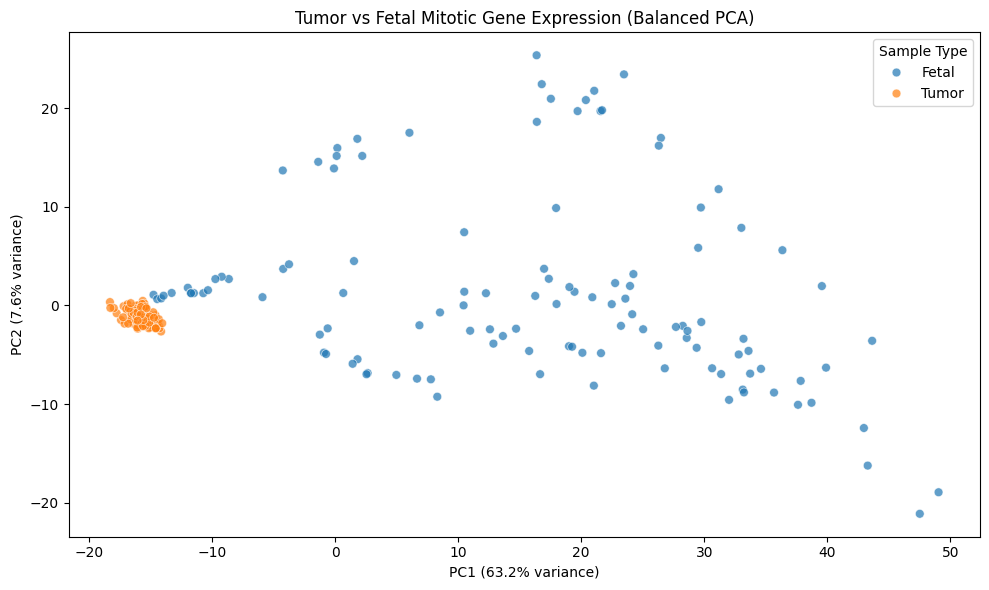

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=joint_pca_df,
    x="PC1",
    y="PC2",
    hue="source",
    alpha=0.7,
    s=40
)

plt.title("Tumor vs Fetal Mitotic Gene Expression (Balanced PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Sample Type")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "joint_pca_balanced.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

After balancing sample sizes, tumor samples cluster tightly within a narrow region of mitotic gene expression space, while fetal samples span a much broader range.

This suggests that tumor proliferation reflects a constrained subset of developmental transcriptional states rather than broadly recapitulating fetal programs.

## Build Fetal Stage–Tissue Reference Profiles

In [23]:
fetal_meta = pd.DataFrame({"sample": fetal_aligned.columns})

def parse_fetal_label(label):
    parts = str(label).split(",", 1)
    stage = parts[0].strip() if len(parts) > 0 else "Unknown"
    tissue = parts[1].strip() if len(parts) > 1 else "Unknown"
    return pd.Series({"stage": stage, "tissue": tissue})

fetal_meta[["stage", "tissue"]] = fetal_meta["sample"].apply(parse_fetal_label)
fetal_meta["stage_tissue"] = fetal_meta["stage"] + " | " + fetal_meta["tissue"]

fetal_samples_by_gene = fetal_aligned.T.copy()
fetal_samples_by_gene["stage_tissue"] = fetal_meta["stage_tissue"].values

fetal_centroids = fetal_samples_by_gene.groupby("stage_tissue").mean().T

print("Fetal centroids shape:", fetal_centroids.shape)

Fetal centroids shape: (596, 119)


## Tumor-to-Fetal Similarity Using Correlation Distance

Tumor samples are compared to fetal stage–tissue centroids using correlation distance, which captures similarity in expression pattern rather than absolute magnitude.

In [24]:
tumor_subset = tumor_aligned.sample(n=500, axis=1, random_state=42)

shared_for_dist = tumor_subset.index.intersection(fetal_centroids.index)

tumor_for_dist = tumor_subset.loc[shared_for_dist].T
fetal_for_dist = fetal_centroids.loc[shared_for_dist].T

tumor_scaled = StandardScaler().fit_transform(tumor_for_dist)
fetal_scaled = StandardScaler().fit_transform(fetal_for_dist)

distance_matrix = cdist(
    tumor_scaled,
    fetal_scaled,
    metric="correlation"
)

distance_df = pd.DataFrame(
    distance_matrix,
    index=tumor_for_dist.index,
    columns=fetal_for_dist.index
)

print("Distance matrix shape:", distance_df.shape)

Distance matrix shape: (500, 119)


In [ ]:
closest_match = distance_df.idxmin(axis=1).rename("closest_fetal_profile")
closest_distance = distance_df.min(axis=1).rename("distance")

tumor_match_df = pd.concat([closest_match, closest_distance], axis=1).reset_index()
tumor_match_df = tumor_match_df.rename(columns={"index": "tumor_sample"})

tumor_match_df["stage"] = tumor_match_df["closest_fetal_profile"].str.split(" \\| ").str[0]
tumor_match_df["tissue"] = tumor_match_df["closest_fetal_profile"].str.split(" \\| ").str[1]

print(tumor_match_df["tissue"].value_counts().head(10))

tumor_match_df.to_csv(TABLES_DIR / "tumor_fetal_matches_corr.csv", index=False)
print("Saved correlation-based matching results.")

tissue
kidney       114
testis        99
forebrain     88
liver         83
hindbrain     70
heart         32
ovary         14
Name: count, dtype: int64
Saved correlation-based matching results.


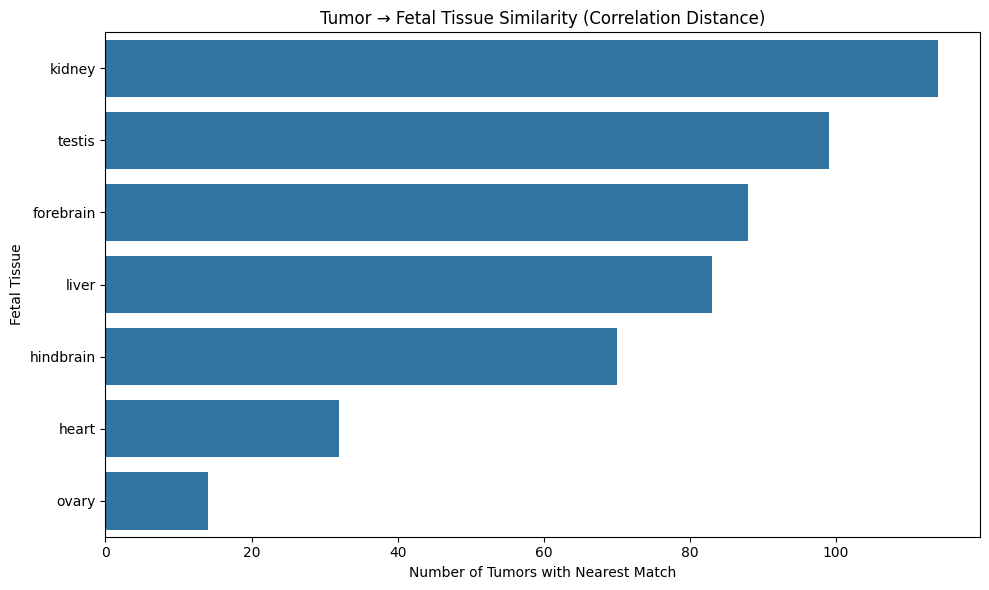

In [ ]:
top_tissues = tumor_match_df["tissue"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_tissues.values, y=top_tissues.index)

plt.title("Tumor → Fetal Tissue Similarity (Correlation Distance)")
plt.xlabel("Number of Tumors with Nearest Match")
plt.ylabel("Fetal Tissue")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_fetal_matches_corr.png", dpi=300, bbox_inches="tight")
plt.show()

## Tumor Subgroups and Developmental Programs

To test whether tumors represent a single proliferative state or multiple related states, we cluster tumor samples based on their mitotic gene expression profiles.

We then examine whether different tumor clusters show different fetal tissue similarities.

In [27]:
from sklearn.cluster import KMeans

# Cluster tumors using the same gene-expression matrix used for matching
X = tumor_for_dist.copy()

# Standardize before clustering
X_scaled = StandardScaler().fit_transform(X)

# Cluster tumors
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Attach cluster labels to the tumor matching results
tumor_cluster_df = tumor_match_df.copy()
tumor_cluster_df["cluster"] = cluster_labels

print(tumor_cluster_df.head())
print(tumor_cluster_df["cluster"].value_counts().sort_index())

      tumor_sample                closest_fetal_profile  distance  \
0  TCGA-FD-A5BV-01      7 week post conception | kidney  0.666397   
1  TCGA-DX-A8BM-01   5 week post conception | forebrain  0.759351   
2  TCGA-DE-A3KN-01                      infant | testis  0.442527   
3  TCGA-EJ-5519-01  11 week post conception | hindbrain  0.574606   
4  TCGA-BP-4160-01      16 week post conception | heart  0.524920   

                     stage     tissue  cluster  
0   7 week post conception     kidney        0  
1   5 week post conception  forebrain        2  
2                   infant     testis        1  
3  11 week post conception  hindbrain        1  
4  16 week post conception      heart        1  
cluster
0    138
1    152
2    165
3     45
Name: count, dtype: int64


## Compare Fetal Tissue Similarity Across Tumor Clusters

Next, we calculate the proportion of tumors in each cluster whose nearest fetal match falls into each tissue category.

In [28]:
cluster_tissue_props = (
    tumor_cluster_df
    .groupby("cluster")["tissue"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

cluster_tissue_props.head(20)

,cluster,tissue,proportion
0,0,liver,0.376812
1,0,kidney,0.188406
2,0,forebrain,0.181159
3,0,testis,0.101449
4,0,heart,0.072464
5,0,hindbrain,0.050725
6,0,ovary,0.028986
7,1,testis,0.473684
8,1,hindbrain,0.230263
9,1,kidney,0.177632


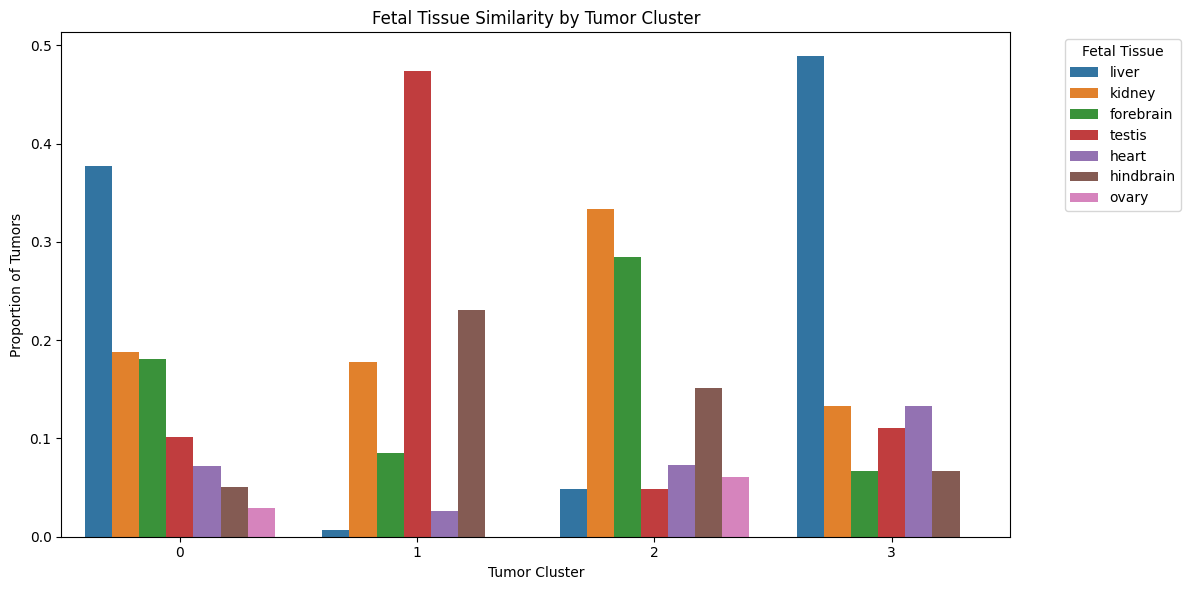

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=cluster_tissue_props,
    x="cluster",
    y="proportion",
    hue="tissue"
)

plt.title("Fetal Tissue Similarity by Tumor Cluster")
plt.xlabel("Tumor Cluster")
plt.ylabel("Proportion of Tumors")
plt.legend(title="Fetal Tissue", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "cluster_fetal_similarity.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

Tumor clusters show different fetal tissue similarity profiles rather than mapping uniformly to a single developmental context.

Some clusters are enriched for liver- and kidney-like matches, while others show stronger similarity to testis or neural tissues. This suggests that tumor proliferation is not one uniform fetal-like program, but a collection of distinct, developmentally related transcriptional states.

In [ ]:
cluster_tissue_props.to_csv(TABLES_DIR / "cluster_fetal_similarity_props.csv", index=False)
tumor_cluster_df.to_csv(TABLES_DIR / "tumor_cluster_matches.csv", index=False)

print("Saved cluster-level similarity tables.")

Saved cluster-level similarity tables.
